In [7]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.spike_detection import *
from utils.preprocess_neural import *


import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})
import matplotlib.cm as cm

import numpy.ma as ma
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import subprocess
import shutil
import pickle
import glob
from utils.GRC_helpers import *

%matplotlib widget


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
data_folder = '../data/CKII_pAce38_PX_20251126'
#data_folder = '../data/CKII_pAce21_PR_20250806'


# turn data_folder into absolute path
data_folder = os.path.abspath(data_folder)
print(f'Loading data from: {data_folder}')

data_name = os.path.basename(data_folder)
figure_save_folder = f'../figures/{data_name}'
figure_save_folder = os.path.abspath(figure_save_folder)
print(f'Figures will be saved to: {figure_save_folder}')
if not os.path.exists(figure_save_folder):
    os.makedirs(figure_save_folder)

Loading data from: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126


In [9]:
# load merged data 

merged_data_path_CS = os.path.join(data_folder, 'merged_aligned_data_CS.pkl')
with open(merged_data_path_CS, 'rb') as f:
    loaded_merged_data_CS = pickle.load(f)
    traces = loaded_merged_data_CS['traces']
    spikes = loaded_merged_data_CS['spikes']
    speed = loaded_merged_data_CS['speed']
    ts_neural = loaded_merged_data_CS['ts_neural']
    x_neural = loaded_merged_data_CS['x_neural']
    y_neural = loaded_merged_data_CS['y_neural']
    hd_angles_neural = loaded_merged_data_CS['hd_angles_neural']
    weights_all = loaded_merged_data_CS['weights_all']
    mean_images = loaded_merged_data_CS['mean_images']
    frame_rate = loaded_merged_data_CS['frame_rate']
    frame_width = loaded_merged_data_CS['frame_width']
    frame_height = loaded_merged_data_CS['frame_height']
    subfolders = loaded_merged_data_CS['subfolders']
    complex_bursts_dicts = loaded_merged_data_CS['complex_bursts_dicts']
    refined_SS = loaded_merged_data_CS['refined_SS']
    all_CS_spikes = loaded_merged_data_CS['all_CS_spikes']
    all_spikes = loaded_merged_data_CS['all_spikes']
    spike_heights_interpolated = loaded_merged_data_CS['spike_heights_interpolated']
    SNR_interpolated = loaded_merged_data_CS['SNR_interpolated']    
    session_start_frames = loaded_merged_data_CS['session_start_frames']
    traces_SNR_interpolated = loaded_merged_data_CS['traces_SNR_interpolated']
    Vm_SNR_interpolated = loaded_merged_data_CS['Vm_SNR_interpolated']
    burst_metrics = loaded_merged_data_CS['burst_metrics']

print(f"Loaded data from {merged_data_path_CS}")



Loaded data from /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/merged_aligned_data_CS.pkl


In [10]:
# Optional: Remove bad SNR segments
spikes = all_spikes.copy()
traces = traces_SNR_interpolated
Vms = Vm_SNR_interpolated

SNR_threshold = 3.5
bad_masks = []

# Now for each cell: remove spikes and make traces and Vms NaN where its SNR_interpolated < SNR_threshold
for cell_idx in range(len(spikes)):
    snr_vals = np.asarray(SNR_interpolated[cell_idx])
    if snr_vals.ndim == 0:
        continue
    bad_mask = snr_vals < SNR_threshold
    bad_masks.append(bad_mask)
    if not np.any(bad_mask):
        continue

    traces[cell_idx][bad_mask] = np.nan
    Vms[cell_idx][bad_mask] = np.nan

    def _filter_spikes(spk_arr, bad_mask_local):
        spk_arr = np.asarray(spk_arr, dtype=np.int64)
        if spk_arr.size == 0:
            return spk_arr
        spk_arr = spk_arr[(spk_arr >= 0) & (spk_arr < bad_mask_local.shape[0])]
        return spk_arr[~bad_mask_local[spk_arr]]

    spikes[cell_idx] = _filter_spikes(spikes[cell_idx], bad_mask)
    all_CS_spikes[cell_idx] = _filter_spikes(all_CS_spikes[cell_idx], bad_mask)
    refined_SS[cell_idx] = _filter_spikes(refined_SS[cell_idx], bad_mask)

    print(f'Cell {cell_idx}: removed {np.sum(bad_mask)} bad SNR frames, spikes reduced from {len(loaded_merged_data_CS["all_spikes"][cell_idx])} to {len(spikes[cell_idx])}')

bad_masks = np.array(bad_masks)

Cell 4: removed 475509 bad SNR frames, spikes reduced from 2620 to 11
Cell 5: removed 298776 bad SNR frames, spikes reduced from 3298 to 219
Cell 8: removed 298776 bad SNR frames, spikes reduced from 2859 to 1220


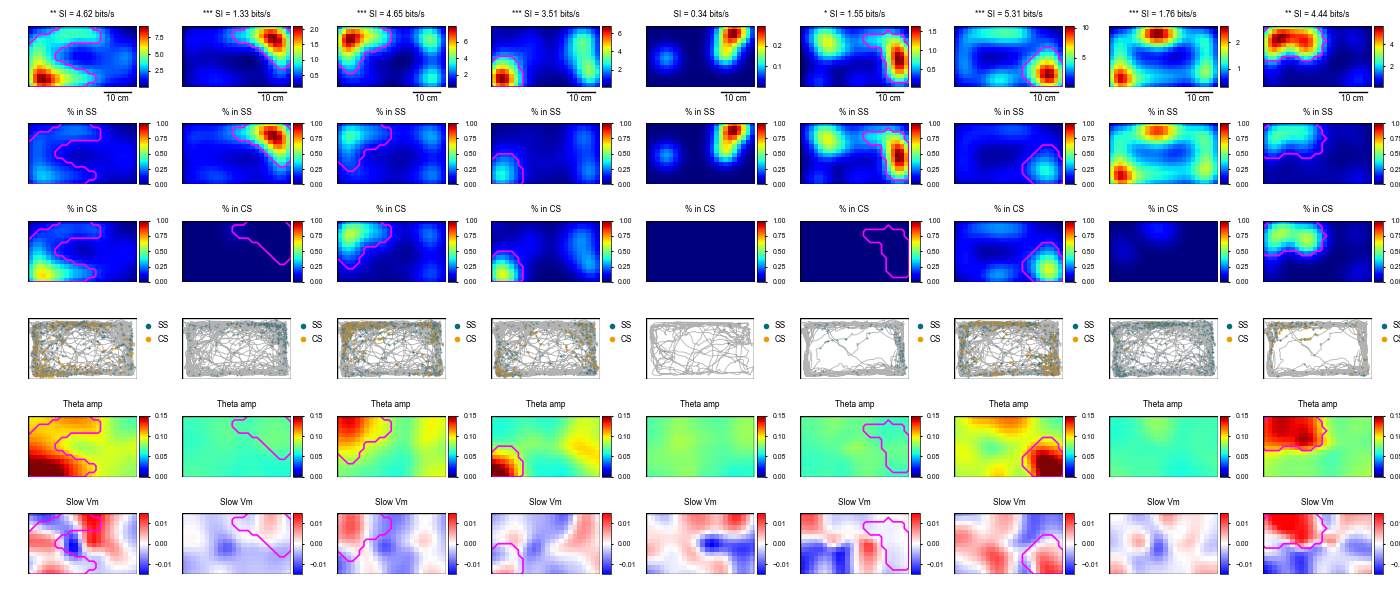

In [11]:
speed_threshold = 3
min_duration_s = 0.25
merge_gap_s = 0
kernel_size = 51
place_field_threshold = 0.3
min_field_bins = 20
max_field_area_ratio = 2/3
PC_output_all = []
theta_freqs = [4, 8]
slow_freqs = 2
fig, axes = plt.subplots(6, len(spikes), figsize=(14,6), sharex=True, sharey=True)
for i, cell_idx in enumerate(range(len(spikes))):
    out = analyze_place_cell_single_moving(
        x_neural, y_neural, spikes, speed, frame_rate,
        cell_idx=i,
        axes=axes[:,i],
        place_field_threshold = place_field_threshold,
        min_field_bins = min_field_bins,
        speed_threshold=speed_threshold,
        kernel_size=kernel_size,
        filter_type="boxcar",
        min_duration_s=min_duration_s, merge_gap_s=merge_gap_s,
        plot_pf_contours=True,
        max_field_area_ratio=max_field_area_ratio,
        bad_timepoints=bad_masks[i] if bad_masks is not None else None,
        num_shuffles=1000,
        random_seed=42,
        plot_sub=True,
        traces=traces,
        theta_freqs=theta_freqs,
        slow_freqs=slow_freqs,
        separate_spikes=True,
        refined_SS=refined_SS,
        all_CS_spikes=all_CS_spikes,
    )
    PC_output_all.append(out)

# Set theta Vm color range for the second to last row
for ax in axes[-2, :]:
    if ax.images:
        ax.images[0].set_clim(0, 0.15)

# Set slow Vm color range for the last row
for ax in axes[-1, :]:
    if ax.images:
        ax.images[0].set_clim(-0.015, 0.015)

plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02, wspace=0.42, hspace=0.1)

# out_path = os.path.join(
#     figure_save_folder,
#     f"place_cell_single_moving_speed{speed_threshold}.svg"
# )
# plt.rcParams["svg.fonttype"] = "none"  # keep text editable in SVG

# fig.savefig(out_path, dpi=300)
# print(f"Saved to {out_path}")



# Single Cell Demo

In [12]:
# GLM: spikes vs behavior (statsmodels)
from utils.GRC_helpers import fit_behavior_glm_statsmodels

cell_idx = 2
frame_rate = frame_rate if 'frame_rate' in globals() else 500

# Use the helper defined earlier in the notebook to extract spike indices per cell
spikes_to_use = spikes
#spikes_to_use = refined_SS
#spikes_to_use = all_CS_spikes
#spikes_to_use = [complex_bursts_dicts[i]['complex_bursts'] for i in range(len(complex_bursts_dicts))]
spike_idx = spikes_to_use[cell_idx]

# Acceleration variable name may differ; update if needed
accel_source = None
trace_for_nan = None
if 'traces' in globals():
    trace_for_nan = traces[cell_idx]
if 'acceleration' in globals():
    accel_source = acceleration
elif 'acc_neural' in globals():
    accel_source = acc_neural

# Get bad_mask for this cell if available
cell_bad_mask = bad_masks[cell_idx] if 'bad_masks' in globals() and len(bad_masks) > cell_idx else None

glm_out = fit_behavior_glm_statsmodels(
    spike_idx,
    x_neural,
    y_neural,
    speed,
    hd_angles_neural,
    frame_rate=frame_rate,
    session_start_frames=session_start_frames,
    accel=accel_source,
    trace_for_nan=trace_for_nan,
    bad_mask=cell_bad_mask,
    bin_size_s=0.3,
    arena_size_cm=(35.5, 20.0),
    rbf_grid=(7, 4),
    rbf_sigma_cm=4.5,
    include_speed_state=False,  # Not needed when moving_only=True
    speed_threshold=speed_threshold,
    moving_only=True,  # Only fit data from moving periods
    include_session=False,
    spike_smooth_sigma_bins=5,
    include_travel_dir=True,
    include_pos_hd = False, 
    include_pos_speed = False,
    include_pos_state =False,
    include_pos_travel_dir =False,
)

from utils.GRC_helpers import glm_coef_table
display(glm_coef_table(glm_out))

,term,coef
0,const,1.158420
1,pos_rbf_0,-1.206732
2,pos_rbf_1,-0.377726
3,pos_rbf_2,0.003437
4,pos_rbf_3,-1.194848
5,pos_rbf_4,0.342597
6,pos_rbf_5,-0.701804
7,pos_rbf_6,0.509025
8,pos_rbf_7,0.281131
9,pos_rbf_8,-1.855202


,covariate,deviance,delta_deviance,pseudo_r2,delta_pseudo_r2,n_params
0,position,2828.790938,577.021791,0.102769,0.183019,6
1,head_direction,2451.982673,200.213527,0.222284,0.063503,32
2,travel_direction,2290.294452,38.525305,0.273568,0.012219,32
3,speed,2255.161674,3.392527,0.284711,0.001076,33
4,accel,2251.780926,0.011779,0.285784,0.000004,33


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_drop_one_cell2.svg


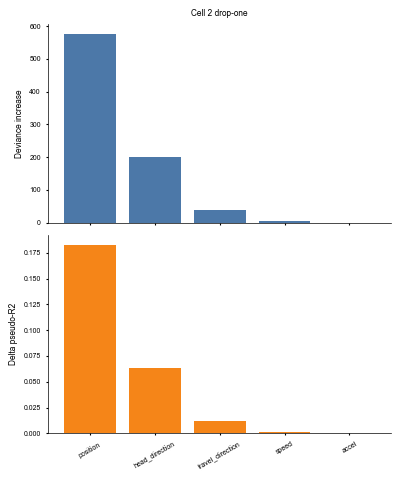

In [13]:
# Drop-one covariate analysis + plot
from utils.GRC_helpers import drop_one_glm_statsmodels, plot_drop_one_metrics

drop_one_df = drop_one_glm_statsmodels(glm_out)
display(drop_one_df)

axes = plot_drop_one_metrics(drop_one_df, title=f'Cell {cell_idx} drop-one')
plt.tight_layout()

out_path = os.path.join(figure_save_folder, f'GLM_drop_one_cell{cell_idx}.svg')
plt.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')


In [14]:
# Test Shuffle GLM significance
from utils.GRC_helpers import shuffle_glm_drop_one_statsmodels

shuffle_out = shuffle_glm_drop_one_statsmodels(
    spike_idx,
    x_neural,
    y_neural,
    speed,
    hd_angles_neural,
    frame_rate=frame_rate,
    session_start_frames=session_start_frames,
    accel=accel_source,
    trace_for_nan=trace_for_nan,
    bad_mask=cell_bad_mask,
    bin_size_s=0.1,
    arena_size_cm=(35.5, 20.0),
    rbf_grid=(7, 4),
    rbf_sigma_cm=4.5,
    include_speed_state=False,  # Not needed when moving_only=True
    speed_threshold=speed_threshold,
    moving_only=True,  # Only fit data from moving periods
    include_session=False,
    spike_smooth_sigma_bins=5,
    include_travel_dir=True,
    include_pos_hd=False,
    include_pos_speed=False,
    include_pos_state=False,
    include_pos_travel_dir=False,
    n_shuffles=100,
    min_shift_s=5.0,
    random_state=0,
)

display(shuffle_out["drop_one_df"])

,covariate,deviance,delta_deviance,pseudo_r2,delta_pseudo_r2,n_params,shuffle_mean,shuffle_std,shuffle_p
0,position,4308.947520,727.272906,0.066030,0.157637,6,0.034815,0.010378,0.009901
1,head_direction,3746.518801,164.844187,0.187937,0.035730,32,0.006685,0.005598,0.009901
2,travel_direction,3613.548583,31.873969,0.216758,0.006909,32,0.001828,0.001455,0.019802
3,speed,3585.712544,4.037930,0.222792,0.000875,33,0.000555,0.000616,0.227723
4,accel,3582.999464,1.324850,0.223380,0.000287,33,0.000066,0.000088,0.049505


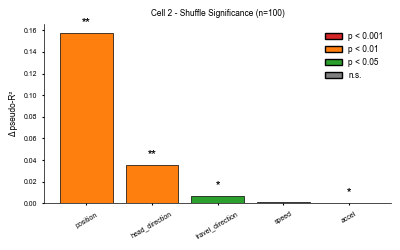

In [15]:
# Visualize shuffle significance results
fig, ax = plt.subplots(1, 1, figsize=(4, 2.5))

df = shuffle_out["drop_one_df"].copy()
covariates = df["covariate"].tolist()
delta_r2 = df["delta_pseudo_r2"].values
shuffle_p = df["shuffle_p"].values

# Color bars by significance
colors = []
for p in shuffle_p:
    if p < 0.001:
        colors.append('#d62728')  # dark red for ***
    elif p < 0.01:
        colors.append('#ff7f0e')  # orange for **
    elif p < 0.05:
        colors.append('#2ca02c')  # green for *
    else:
        colors.append('#7f7f7f')  # gray for n.s.

bars = ax.bar(covariates, delta_r2, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.7)

# Add significance stars
for i, (bar, p) in enumerate(zip(bars, shuffle_p)):
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = ''
    if stars:
        height = bar.get_height()
        offset = 0.005 if height >= 0 else -0.015
        va = 'bottom' if height >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, height + offset, stars,
                ha='center', va=va, fontsize=8, fontweight='bold')

ax.set_ylabel('Δ pseudo-R²')
ax.set_title(f'Cell {cell_idx} - Shuffle Significance (n={shuffle_out["n_shuffles"]})')
ax.tick_params(axis='x', labelrotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', edgecolor='black', label='p < 0.001'),
    Patch(facecolor='#ff7f0e', edgecolor='black', label='p < 0.01'),
    Patch(facecolor='#2ca02c', edgecolor='black', label='p < 0.05'),
    Patch(facecolor='#7f7f7f', edgecolor='black', label='n.s.'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=6)

plt.tight_layout()

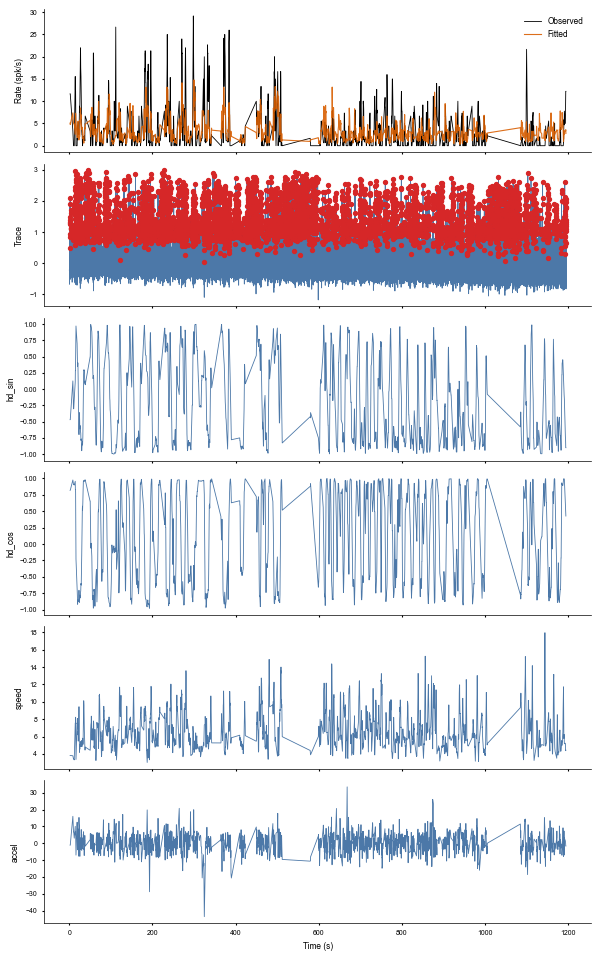

In [16]:
# Observed vs fitted firing rate with voltage trace + spikes
from utils.GRC_helpers import plot_observed_vs_fitted_rate

voltage_trace = None
if 'traces' in globals():
    voltage_trace = traces[cell_idx]

axes = plot_observed_vs_fitted_rate(
    glm_out,
    voltage_trace=voltage_trace,
    frame_rate=frame_rate,
    spike_frames=spike_idx,
    plot_behaviors=True,                 # use behavior_bins from glm_out
    behavior_keys=["hd_sin", "hd_cos", "speed", "accel"],
)


plt.tight_layout()


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_41039/1929489431.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


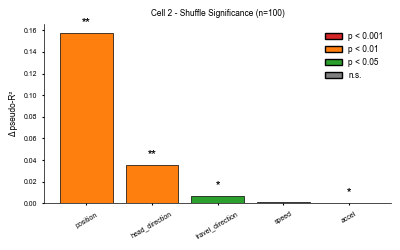

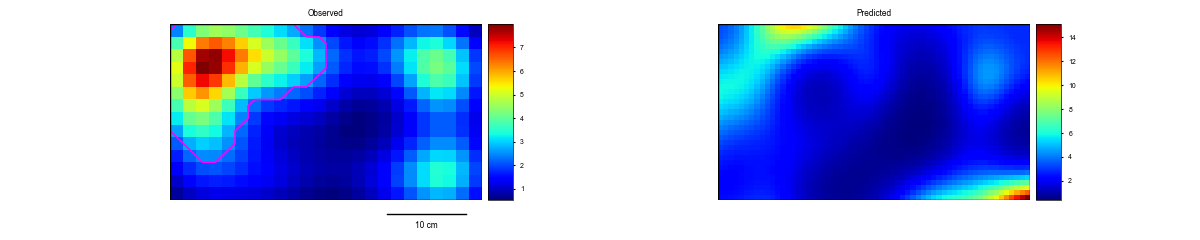

In [17]:
# Visualize shuffle significance results
fig, ax = plt.subplots(1, 1, figsize=(4, 2.5))

df = shuffle_out["drop_one_df"].copy()
covariates = df["covariate"].tolist()
delta_r2 = df["delta_pseudo_r2"].values
shuffle_p = df["shuffle_p"].values

# Color bars by significance
colors = []
for p in shuffle_p:
    if p < 0.001:
        colors.append('#d62728')  # dark red for ***
    elif p < 0.01:
        colors.append('#ff7f0e')  # orange for **
    elif p < 0.05:
        colors.append('#2ca02c')  # green for *
    else:
        colors.append('#7f7f7f')  # gray for n.s.

bars = ax.bar(covariates, delta_r2, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.7)

# Add significance stars
for i, (bar, p) in enumerate(zip(bars, shuffle_p)):
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = ''
    if stars:
        height = bar.get_height()
        offset = 0.005 if height >= 0 else -0.015
        va = 'bottom' if height >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, height + offset, stars,
                ha='center', va=va, fontsize=8, fontweight='bold')

ax.set_ylabel('Δ pseudo-R²')
ax.set_title(f'Cell {cell_idx} - Shuffle Significance (n={shuffle_out["n_shuffles"]})')
ax.tick_params(axis='x', labelrotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', edgecolor='black', label='p < 0.001'),
    Patch(facecolor='#ff7f0e', edgecolor='black', label='p < 0.01'),
    Patch(facecolor='#2ca02c', edgecolor='black', label='p < 0.05'),
    Patch(facecolor='#7f7f7f', edgecolor='black', label='n.s.'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=6)

plt.tight_layout()# Observed vs predicted spatial maps (style matched)
from utils.GRC_helpers import analyze_place_cell_single_moving, plot_observed_and_predicted_spatial_maps

pc_out = analyze_place_cell_single_moving(
    x_neural, y_neural, spikes_to_use, speed, frame_rate,
    cell_idx=cell_idx,
    place_field_threshold = place_field_threshold,
    min_field_bins = min_field_bins,
    speed_threshold=speed_threshold,
    kernel_size=kernel_size,
    filter_type="boxcar",
    min_duration_s=min_duration_s, merge_gap_s=merge_gap_s,
    plot_pf_contours=True,
    max_field_area_ratio=max_field_area_ratio
)

axes, pred_map = plot_observed_and_predicted_spatial_maps(
    pc_out,
    glm_out,
    plot_pf_contours=True,
)
plt.tight_layout()


# All cells

In [18]:
# Summary for all cells + violin plots of delta pseudo-R2
from utils.GRC_helpers import (
    fit_behavior_glm_statsmodels,
    drop_one_glm_statsmodels,
    analyze_place_cell_single_moving,
    plot_observed_and_predicted_spatial_maps,
)

spike_sources = [
    ('All spikes', spikes),
    ('Simple spikes', refined_SS),
    ('Complex spikes', all_CS_spikes),
]

delta_records = []
min_spikes = 10


for cell_idx in range(len(spikes)):
    fig, axes = plt.subplots(3, 3, figsize=(9, 7), sharex=False, sharey=False)

    # Get bad_mask for this cell if available
    cell_bad_mask = bad_masks[cell_idx] if 'bad_masks' in globals() and len(bad_masks) > cell_idx else None

    for row_idx, (label, spikes_source) in enumerate(spike_sources):
        spike_idx = spikes_source[cell_idx]

        if len(spike_idx) < min_spikes:
            covariate_order = [
                'position',
                'head_direction',
                'speed',
                'travel_direction',
                'accel',
            ]
            drop_one_df = pd.DataFrame({
                'covariate': covariate_order,
                'delta_pseudo_r2': np.nan,
            })
            drop_one_df['cell_idx'] = cell_idx
            drop_one_df['spike_source'] = label
            delta_records.append(drop_one_df)

            ax_r2 = axes[row_idx, 0]
            ax_r2.set_title(f'{label} n<10', fontsize=7)
            ax_r2.cla()
            ax_r2.axis('off')
            axes[row_idx, 1].cla()
            axes[row_idx, 2].cla()
            axes[row_idx, 1].axis('off')
            axes[row_idx, 2].axis('off')
            continue

        accel_source = None
        if 'acceleration' in globals():
            accel_source = acceleration
        elif 'acc_neural' in globals():
            accel_source = acc_neural

        try:
            glm_out = fit_behavior_glm_statsmodels(
                spike_idx,
                x_neural,
                y_neural,
                speed,
                hd_angles_neural,
                frame_rate=frame_rate,
                session_start_frames=session_start_frames,
                accel=accel_source,
                trace_for_nan=traces[cell_idx] if 'traces' in globals() else None,
                bad_mask=cell_bad_mask,
                bin_size_s=0.1,
                arena_size_cm=(35.5, 20.0),
                rbf_grid=(7, 4),
                rbf_sigma_cm=4.5,
                include_session=False,
                include_speed_state=False,  # Not needed when moving_only=True
                speed_threshold=speed_threshold,
                moving_only=True,  # Only fit data from moving periods
                spike_smooth_sigma_bins=5,
                include_pos_hd=False,
                include_pos_speed=False,
                include_pos_state=False,
                include_travel_dir=True,
                include_pos_travel_dir=False,
            )
        except (ValueError, Exception) as e:
            print(f"Cell {cell_idx}, {label}: GLM fitting failed - {e}")
            covariate_order = [
                'position',
                'head_direction',
                'state',
                'speed',
                'travel_direction',
                'accel',
            ]
            drop_one_df = pd.DataFrame({
                'covariate': covariate_order,
                'delta_pseudo_r2': np.nan,
            })
            drop_one_df['cell_idx'] = cell_idx
            drop_one_df['spike_source'] = label
            delta_records.append(drop_one_df)

            ax_r2 = axes[row_idx, 0]
            ax_r2.set_title(f'{label} (fit failed)', fontsize=7)
            ax_r2.cla()
            ax_r2.axis('off')
            axes[row_idx, 1].cla()
            axes[row_idx, 2].cla()
            axes[row_idx, 1].axis('off')
            axes[row_idx, 2].axis('off')
            continue

        drop_one_df = drop_one_glm_statsmodels(glm_out)
        drop_one_df = drop_one_df.copy()
        drop_one_df['cell_idx'] = cell_idx
        drop_one_df['spike_source'] = label
        delta_records.append(drop_one_df)

        ax_r2 = axes[row_idx, 0]
        ax_r2.bar(drop_one_df['covariate'], drop_one_df['delta_pseudo_r2'], color='#f58518')
        ax_r2.axhline(0, color='black', linewidth=0.7)
        ax_r2.set_title(f'{label} Δpseudo-R2', fontsize=7)
        ax_r2.set_ylabel('Δ pseudo-R2')
        ax_r2.tick_params(axis='x', labelrotation=30, labelsize=6)
        ax_r2.spines['top'].set_visible(False)
        ax_r2.spines['right'].set_visible(False)

        pc_out = analyze_place_cell_single_moving(
            x_neural, y_neural, spikes_source, speed, frame_rate,
            cell_idx=cell_idx,
            axes=None,
            place_field_threshold=place_field_threshold,
            min_field_bins=min_field_bins,
            speed_threshold=speed_threshold,
            kernel_size=kernel_size,
            filter_type='boxcar',
            min_duration_s=min_duration_s,
            merge_gap_s=merge_gap_s,
            plot_pf_contours=True,
            max_field_area_ratio=max_field_area_ratio,
        )

        plot_observed_and_predicted_spatial_maps(
            pc_out,
            glm_out,
            axes=axes[row_idx, 1:3],
            plot_pf_contours=True,
        )

    plt.tight_layout()
    out_path = os.path.join(figure_save_folder, f'GLM_summary_cell{cell_idx}.svg')
    fig.savefig(out_path, dpi=300)
    plt.close(fig)
    print(f'Saved to {out_path}')

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_41039/1825346239.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_summary_cell0.svg


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_41039/1825346239.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_summary_cell1.svg


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_41039/1825346239.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


...

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_summary_cell6.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:143: RuntimeWarning: divide by zero encountered in divide
  return 1. / (self.link.deriv(mu)**2 * self.variance(mu))
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_41039/1825346239.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_summary_cell7.svg


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_41039/1825346239.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_summary_cell8.svg


In [19]:
PC_indices = [i for i, pc_out in enumerate(PC_output_all) if pc_out['is_place_cell']]
print(f'Identified {len(PC_indices)} place cells out of {len(spikes)} total cells.')
print(f'Place cell indices: {PC_indices}')

Identified 7 place cells out of 9 total cells.
Place cell indices: [0, 1, 2, 3, 5, 6, 8]


Saved delta_plot to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_summary_singleFOV_delta_plot.csv
Saved stats_df to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_summary_singleFOV_stats.csv


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_41039/4093562881.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delta_plot['is_place_cell'] = delta_plot['cell_idx'].map(pc_flag_map)


,covariate,comparison,p_value,test,n_pairs
0,position,A-S,0.062500,wilcoxon,7
1,position,A-C,0.562500,wilcoxon,6
2,position,S-C,0.031250,wilcoxon,6
3,head_direction,A-S,0.997890,ttest,7
4,head_direction,A-C,0.843750,wilcoxon,6
5,head_direction,S-C,0.643672,ttest,6
6,travel_direction,A-S,0.757776,ttest,7
7,travel_direction,A-C,0.621386,ttest,6
8,travel_direction,S-C,0.919311,ttest,6
9,speed,A-S,0.072997,ttest,7


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pAce38_PX_20251126/GLM_drop_one_violin_all_cells.svg


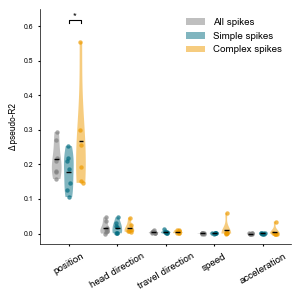

In [20]:

from matplotlib.patches import Patch
onlyPC = True  # Set to True to include only place cells in the violin plot

delta_all = pd.concat(delta_records, ignore_index=True)

if onlyPC:
    pc_indices = [i for i, out in enumerate(PC_output_all) if out.get('is_place_cell', False)]
    delta_plot = delta_all[delta_all['cell_idx'].isin(pc_indices)]
else:
    delta_plot = delta_all

order_df = (
    delta_plot[delta_plot['spike_source'] == 'All spikes']
    .groupby('covariate')['delta_pseudo_r2']
    .mean()
    .sort_values(ascending=False)
)
covariates = order_df.index.tolist()

colors = {
    'All spikes': 'gray',
    'Simple spikes': '#026C80',
    'Complex spikes': '#EE9B00',
}

def _paired_test(values_a, values_b):
    if len(values_a) < 3:
        return np.nan, 'n<3', len(values_a)
    diff = values_a - values_b
    if np.allclose(diff, 0):
        return 1.0, 'zero', len(values_a)
    try:
        shapiro_p = stats.shapiro(diff).pvalue
    except Exception:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p > 0.05:
        _, p = stats.ttest_rel(values_a, values_b, nan_policy='omit')
        return p, 'ttest', len(values_a)
    try:
        _, p = stats.wilcoxon(values_a, values_b)
        return p, 'wilcoxon', len(values_a)
    except Exception:
        return np.nan, 'wilcoxon_fail', len(values_a)

stats_rows = []
comparisons = [
    ('All spikes', 'Simple spikes', 'A-S'),
    ('All spikes', 'Complex spikes', 'A-C'),
    ('Simple spikes', 'Complex spikes', 'S-C'),
]

for cov in covariates:
    for src_a, src_b, label in comparisons:
        df_a = delta_plot[(delta_plot['spike_source'] == src_a) & (delta_plot['covariate'] == cov)][['cell_idx', 'delta_pseudo_r2']]
        df_b = delta_plot[(delta_plot['spike_source'] == src_b) & (delta_plot['covariate'] == cov)][['cell_idx', 'delta_pseudo_r2']]
        merged = df_a.merge(df_b, on='cell_idx', suffixes=('_a', '_b'))
        # Drop rows with NaN in either column
        merged = merged.dropna(subset=['delta_pseudo_r2_a', 'delta_pseudo_r2_b'])
        p, test_name, n = _paired_test(merged['delta_pseudo_r2_a'].values, merged['delta_pseudo_r2_b'].values)
        stats_rows.append({
            'covariate': cov,
            'comparison': label,
            'p_value': p,
            'test': test_name,
            'n_pairs': n,
        })

stats_df = pd.DataFrame(stats_rows)

pc_flag = [out.get('is_place_cell', False) for out in PC_output_all]
pc_flag_map = dict(enumerate(pc_flag))
delta_plot['is_place_cell'] = delta_plot['cell_idx'].map(pc_flag_map)

summary_prefix = 'GLM_summary_singleFOV'
summary_out_dir = figure_save_folder
delta_csv = os.path.join(summary_out_dir, f'{summary_prefix}_delta_plot.csv')
stats_csv = os.path.join(summary_out_dir, f'{summary_prefix}_stats.csv')

# Save for cross-FOV aggregation
delta_plot.to_csv(delta_csv, index=False)
stats_df.to_csv(stats_csv, index=False)
print(f'Saved delta_plot to {delta_csv}')
print(f'Saved stats_df to {stats_csv}')
display(stats_df)

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
offsets = {'All spikes': -0.25, 'Simple spikes': 0.0, 'Complex spikes': 0.25}
width = 0.2

for src_label, _ in spike_sources:
    data = []
    positions = []
    for i, cov in enumerate(covariates):
        vals = delta_plot[(delta_plot['spike_source'] == src_label) & (delta_plot['covariate'] == cov)]['delta_pseudo_r2']
        vals_clean = vals.dropna().values  # Remove NaN values
        data.append(vals_clean)
        positions.append(i + 1 + offsets[src_label])
    
    # Filter out empty arrays for violin plot
    valid_data = []
    valid_positions = []
    for d, p in zip(data, positions):
        if len(d) > 0:
            valid_data.append(d)
            valid_positions.append(p)
    
    if len(valid_data) == 0:
        continue  # Skip if no valid data for this spike source
    
    parts = ax.violinplot(
        valid_data,
        positions=valid_positions,
        widths=width,
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )
    if 'cmeans' in parts:
        parts['cmeans'].set_color('black')
        parts['cmeans'].set_linewidth(1.0)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[src_label])
        pc.set_alpha(0.5)
        pc.set_edgecolor('none')

    for pos, vals in zip(positions, data):
        if len(vals) == 0:
            continue
        jitter = (np.random.rand(len(vals)) - 0.5) * 0.08
        ax.scatter(
            np.full_like(vals, pos, dtype=float) + jitter,
            vals,
            s=10,
            color=colors[src_label],
            alpha=0.7,
            linewidths=0,
        )

label_map = {
    'position': 'position',
    'head_direction': 'head direction',
    'speed': 'speed',
    'travel_direction': 'travel direction',
    'accel': 'acceleration',
}
ax.set_xticks(range(1, len(covariates) + 1))
ax.set_xticklabels([
    label_map.get(cov, cov) for cov in covariates
], rotation=30, fontsize=7)
ax.set_ylabel('Δ pseudo-R2')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_handles = [
    Patch(facecolor=colors[label], edgecolor='none', alpha=0.5, label=label)
    for label in ['All spikes', 'Simple spikes', 'Complex spikes']
]
ax.legend(handles=legend_handles, frameon=False, fontsize=7, loc='upper right')

# Annotate significant pairwise comparisons
comp_pairs = [
    ('A-S', 'All spikes', 'Simple spikes'),
    ('A-C', 'All spikes', 'Complex spikes'),
    ('S-C', 'Simple spikes', 'Complex spikes'),
]

for i, cov in enumerate(covariates):
    cov_stats = stats_df[stats_df['covariate'] == cov]
    cov_vals = delta_plot[delta_plot['covariate'] == cov]['delta_pseudo_r2']
    if cov_vals.empty:
        continue
    y_max = np.nanmax(cov_vals.values)
    y_min = np.nanmin(cov_vals.values)
    y_range = y_max - y_min if np.isfinite(y_max - y_min) else 1.0
    base_offset = max(0.12 * y_range, 0.04)
    y0 = y_max + base_offset
    sig_idx = 0
    for label, a, b in comp_pairs:
        row = cov_stats[cov_stats['comparison'] == label]
        if row.empty:
            continue
        p = row['p_value'].values[0]
        if not np.isfinite(p) or p >= 0.05:
            continue
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        else:
            stars = '*'
        x1 = i + 1 + offsets[a]
        x2 = i + 1 + offsets[b]
        y = y0 + sig_idx * base_offset
        ax.plot([x1, x1, x2, x2], [y, y + 0.18 * base_offset, y + 0.18 * base_offset, y], color='black', linewidth=0.8)
        ax.text((x1 + x2) / 2, y + 0.1 * base_offset, stars, ha='center', va='bottom', fontsize=7)
        sig_idx += 1

plt.tight_layout()
summary_out = os.path.join(figure_save_folder, 'GLM_drop_one_violin_all_cells.svg')
fig.savefig(summary_out, dpi=300)
print(f'Saved to {summary_out}')
